# 📊 Task 3: Exploratory Data Analysis (EDA)
---
**Objective:** Perform comprehensive EDA on the cleaned Titanic dataset — generating descriptive statistics, rich visualizations, and deriving actionable insights about survival patterns, passenger demographics, and fare distributions.

**Dataset Used:** [Cleaned Titanic Dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) (cleaned inline from Task 2 pipeline)

**Direct CSV URL (for Google Colab):**
```
https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
```

---
**Author:** Data Science Lab  
**Tools:** Python, Pandas, Matplotlib, Seaborn, NumPy, SciPy


## 🔧 Step 1: Install & Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings, os
from datetime import datetime
warnings.filterwarnings('ignore')

# Professional plotting style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi"     : 120,
    "axes.titlesize" : 12,
    "axes.labelsize" : 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family"    : "DejaVu Sans",
})

OUTPUT_DIR = "eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Libraries ready!")
print(f"📅 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ Libraries ready!
📅 2026-05-30 07:47:05


## 📥 Step 2: Load & Quick-Clean Dataset

In [2]:
CSV_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw  = pd.read_csv(CSV_URL)

# Minimal cleaning for EDA
df = df_raw.copy()
df["Age"]         = df.groupby(["Pclass","Sex"])["Age"].transform(lambda x: x.fillna(x.median()))
df["Has_Cabin"]   = df["Cabin"].notna().astype(int)
df["Embarked"]    = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Family_Size"] = df["SibSp"] + df["Parch"] + 1
df["Is_Alone"]    = (df["Family_Size"] == 1).astype(int)
df["Age_Group"]   = pd.cut(df["Age"], bins=[0,12,18,35,60,100],
                            labels=["Child","Teen","Young Adult","Adult","Senior"])
df["Fare"]        = df["Fare"].clip(upper=df["Fare"].quantile(0.99))

print(f"✅ Dataset loaded  →  {df.shape[0]:,} rows × {df.shape[1]} cols")
df.head()


✅ Dataset loaded  →  891 rows × 16 cols


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_Cabin,Family_Size,Is_Alone,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,2,0,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,2,0,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,1,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,2,0,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,1,Young Adult


## 📋 Step 3: Descriptive Statistics

In [3]:
print("=" * 70)
print("                 DESCRIPTIVE STATISTICS REPORT")
print("=" * 70)

numeric_cols = ["Age","Fare","SibSp","Parch","Family_Size"]
desc         = df[numeric_cols].describe().T
desc["skewness"] = df[numeric_cols].skew().round(3)
desc["kurtosis"] = df[numeric_cols].kurt().round(3)
desc["median"]   = df[numeric_cols].median()
desc["mode"]     = df[numeric_cols].mode().iloc[0]
desc["IQR"]      = desc["75%"] - desc["25%"]

print("\n📊 Numerical Columns:")
print(desc[["count","mean","std","min","25%","50%","75%","max",
            "skewness","kurtosis","IQR"]].round(2).to_string())

print("\n\n📊 Categorical Columns:")
cat_cols = ["Survived","Pclass","Sex","Embarked","Age_Group"]
for col in cat_cols:
    vc = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    print(f"\n  🔹 {col}:")
    for val, cnt in vc.items():
        print(f"      {str(val):<15}: {cnt:>4}  ({pct[val]:>5.1f}%)")


                 DESCRIPTIVE STATISTICS REPORT

📊 Numerical Columns:
             count   mean    std   min    25%    50%   75%     max  skewness  kurtosis    IQR
Age          891.0  29.11  13.30  0.42  21.50  26.00  36.0   80.00      0.53      0.72  14.50
Fare         891.0  31.22  42.52  0.00   7.91  14.45  31.0  249.01      3.11     11.03  23.09
SibSp        891.0   0.52   1.10  0.00   0.00   0.00   1.0    8.00      3.70     17.88   1.00
Parch        891.0   0.38   0.81  0.00   0.00   0.00   0.0    6.00      2.75      9.78   0.00
Family_Size  891.0   1.90   1.61  1.00   1.00   1.00   2.0   11.00      2.73      9.16   1.00


📊 Categorical Columns:

  🔹 Survived:
      0              :  549  ( 61.6%)
      1              :  342  ( 38.4%)

  🔹 Pclass:
      3              :  491  ( 55.1%)
      1              :  216  ( 24.2%)
      2              :  184  ( 20.7%)

  🔹 Sex:
      male           :  577  ( 64.8%)
      female         :  314  ( 35.2%)

  🔹 Embarked:
      S              : 

## 📊 Step 4: Univariate Analysis — Numerical Variables

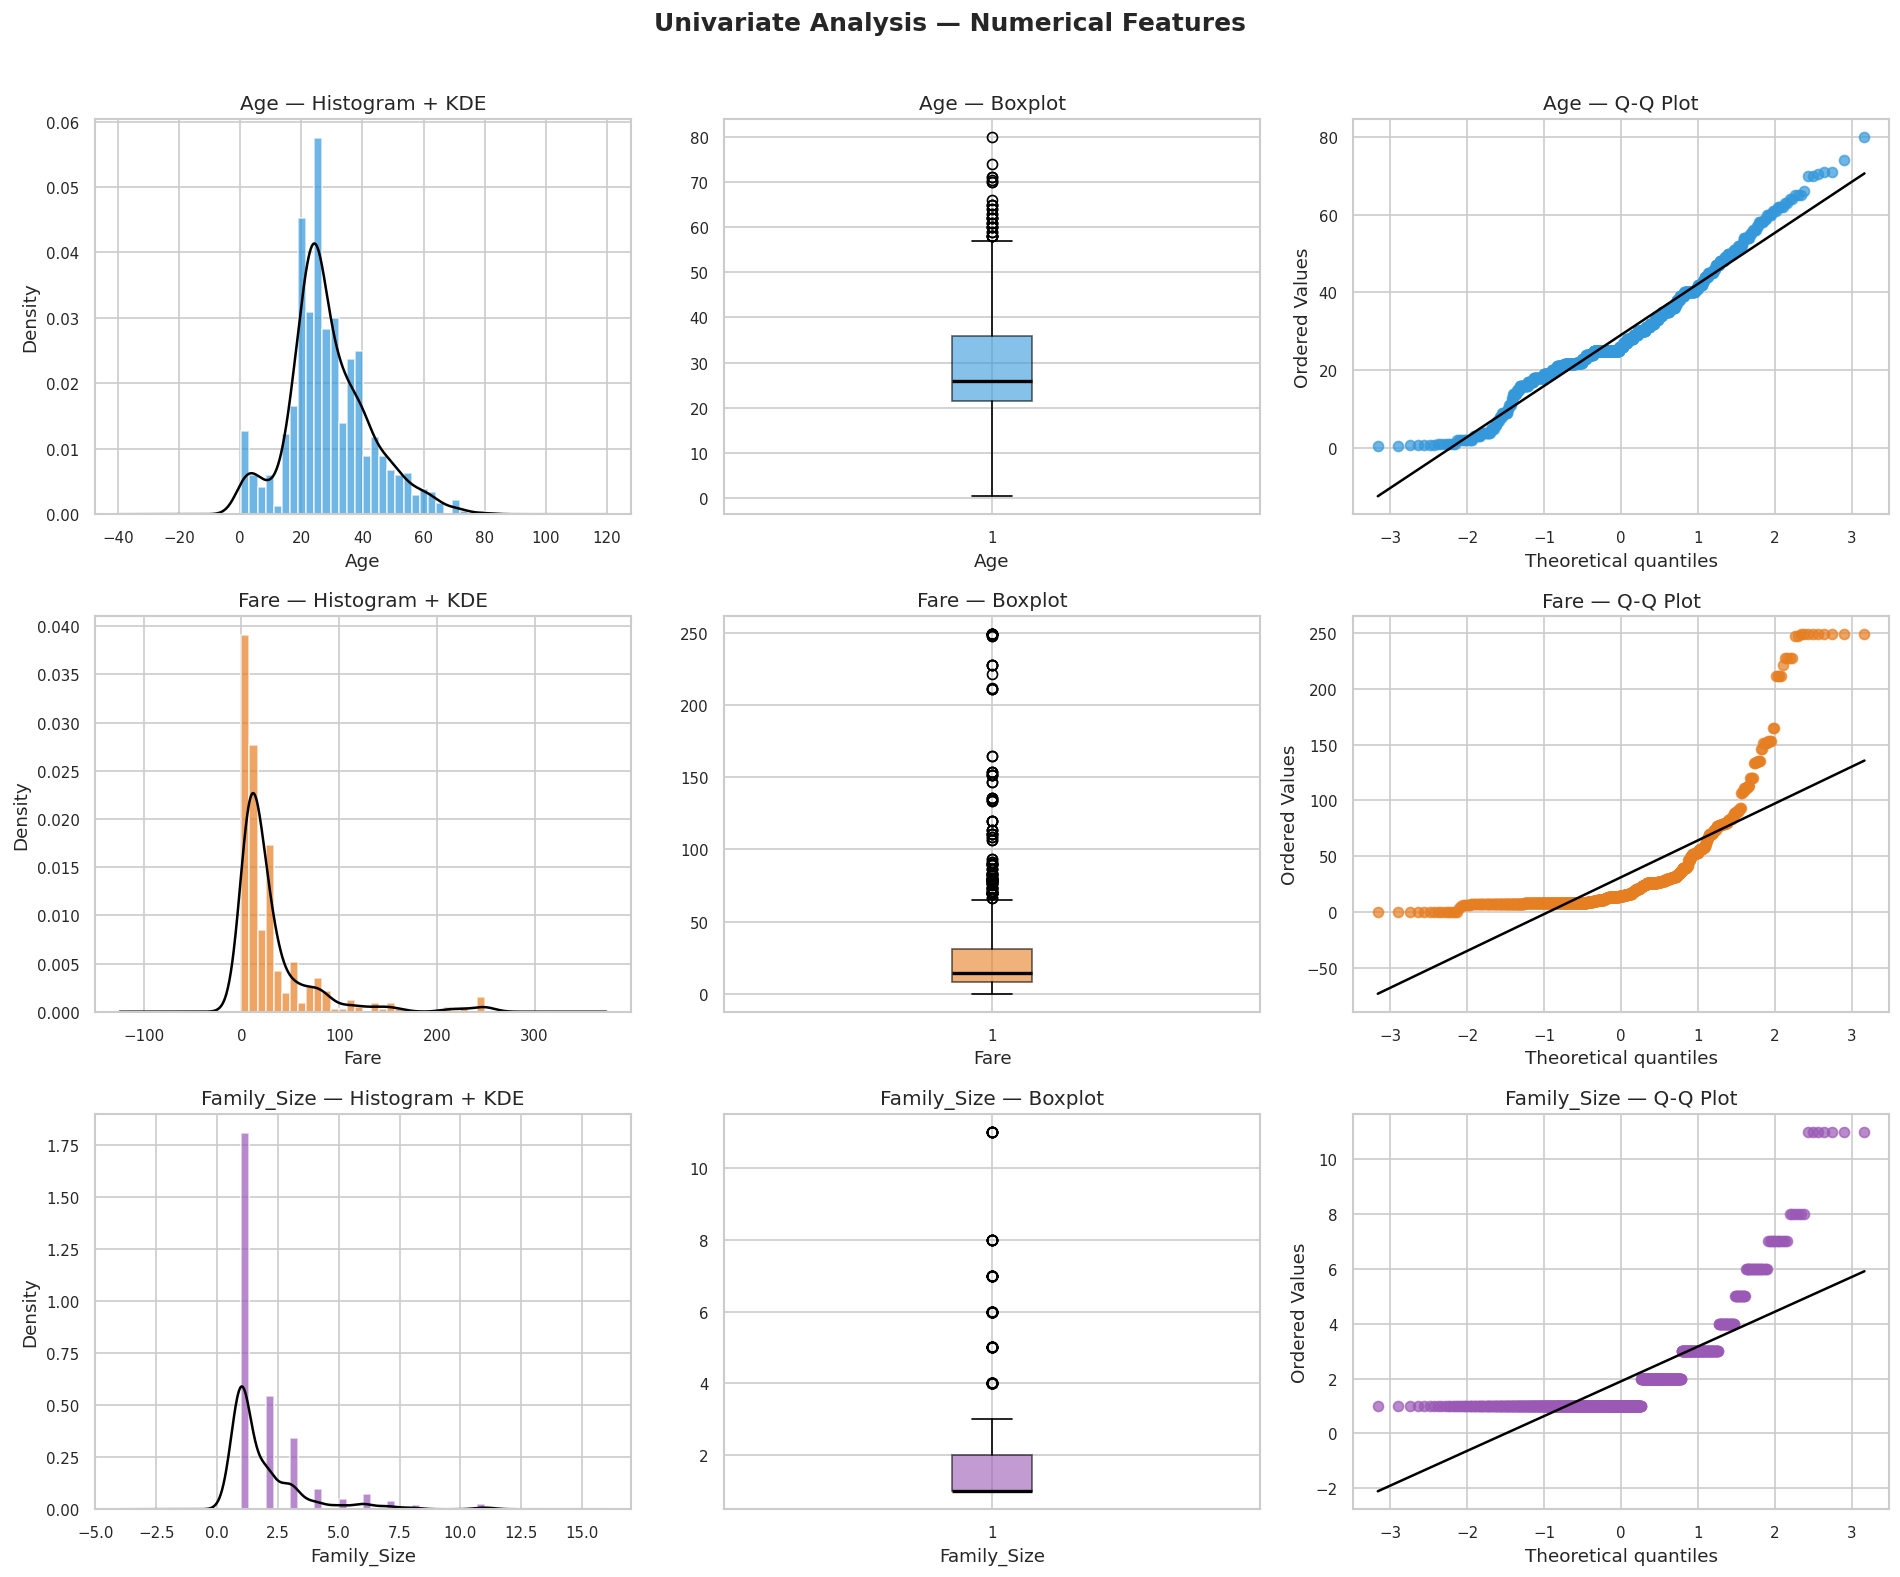

📊 Univariate numerical chart saved.


In [4]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Univariate Analysis — Numerical Features", fontsize=15, fontweight="bold", y=1.01)

num_features = ["Age","Fare","Family_Size"]
colors       = ["#3498DB","#E67E22","#9B59B6"]

for i, (col, color) in enumerate(zip(num_features, colors)):
    # Histogram + KDE
    axes[i,0].hist(df[col].dropna(), bins=30, color=color, alpha=0.7, edgecolor="white", density=True)
    df[col].dropna().plot(kind="kde", ax=axes[i,0], color="black", lw=1.5)
    axes[i,0].set_title(f"{col} — Histogram + KDE")
    axes[i,0].set_xlabel(col)
    axes[i,0].set_ylabel("Density")

    # Boxplot
    axes[i,1].boxplot(df[col].dropna(), patch_artist=True,
                      boxprops=dict(facecolor=color, alpha=0.6),
                      medianprops=dict(color="black", lw=2))
    axes[i,1].set_title(f"{col} — Boxplot")
    axes[i,1].set_xlabel(col)

    # QQ-plot
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i,2])
    axes[i,2].set_title(f"{col} — Q-Q Plot")
    axes[i,2].get_lines()[0].set(color=color, alpha=0.7)
    axes[i,2].get_lines()[1].set(color="black", lw=1.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_univariate_numerical.png"), bbox_inches="tight")
plt.show()
print("📊 Univariate numerical chart saved.")


## 📊 Step 5: Univariate Analysis — Categorical Variables

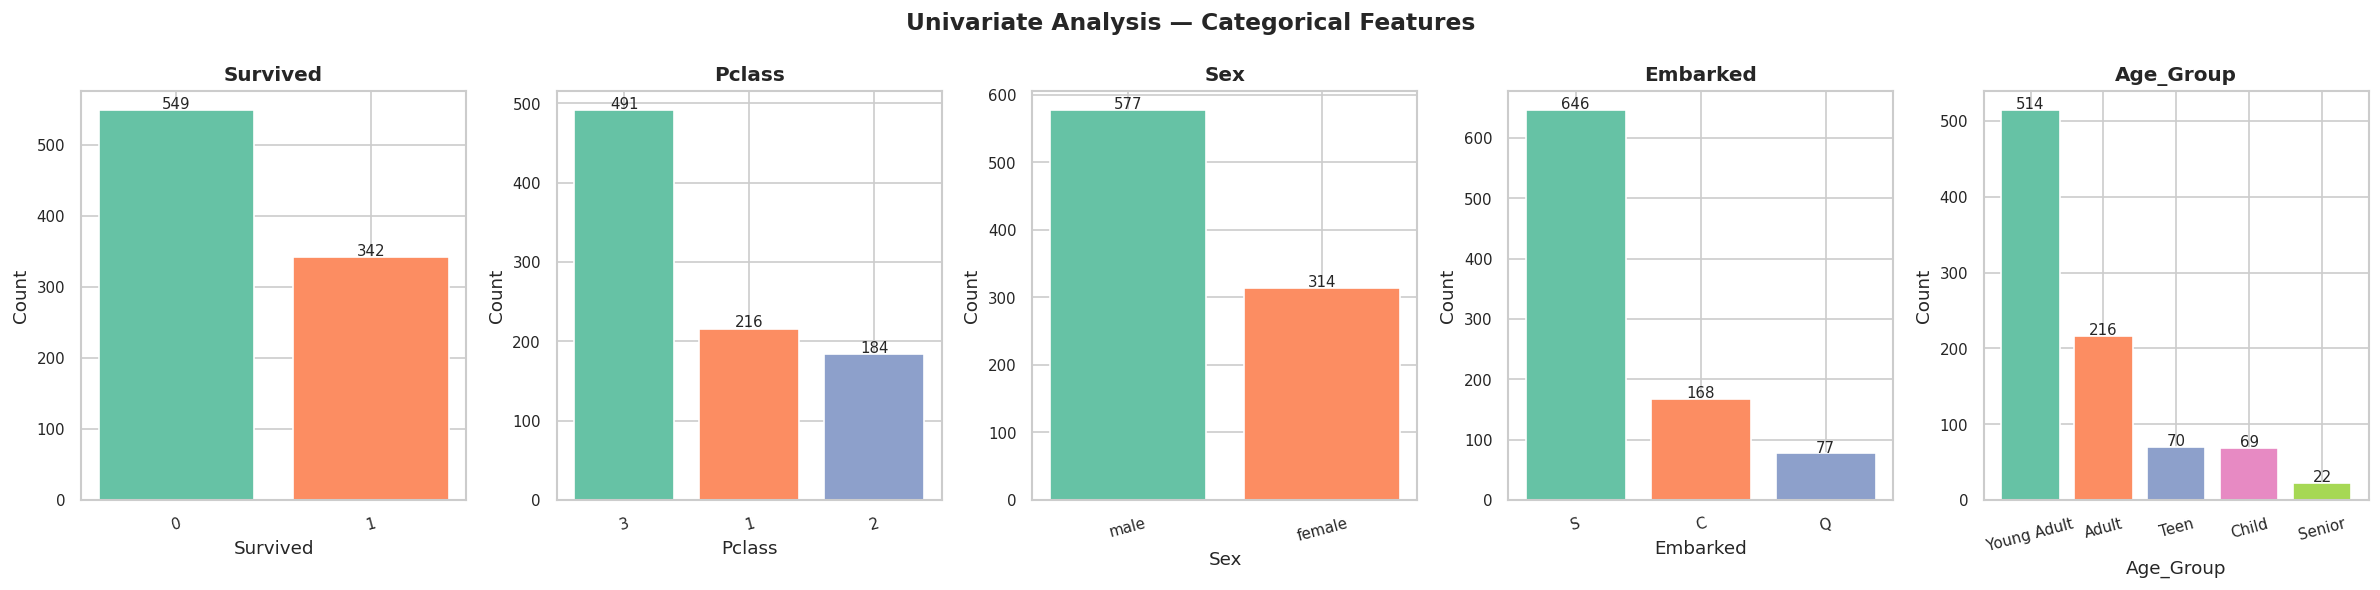

📊 Univariate categorical chart saved.


In [5]:
cat_features = ["Survived","Pclass","Sex","Embarked","Age_Group"]
palette      = sns.color_palette("Set2", 6)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Univariate Analysis — Categorical Features", fontsize=14, fontweight="bold")

for ax, col in zip(axes, cat_features):
    vc = df[col].value_counts()
    bars = ax.bar(vc.index.astype(str), vc.values, color=palette[:len(vc)], edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_univariate_categorical.png"), bbox_inches="tight")
plt.show()
print("📊 Univariate categorical chart saved.")


## 📊 Step 6: Survival Analysis — Key Bivariate Plots

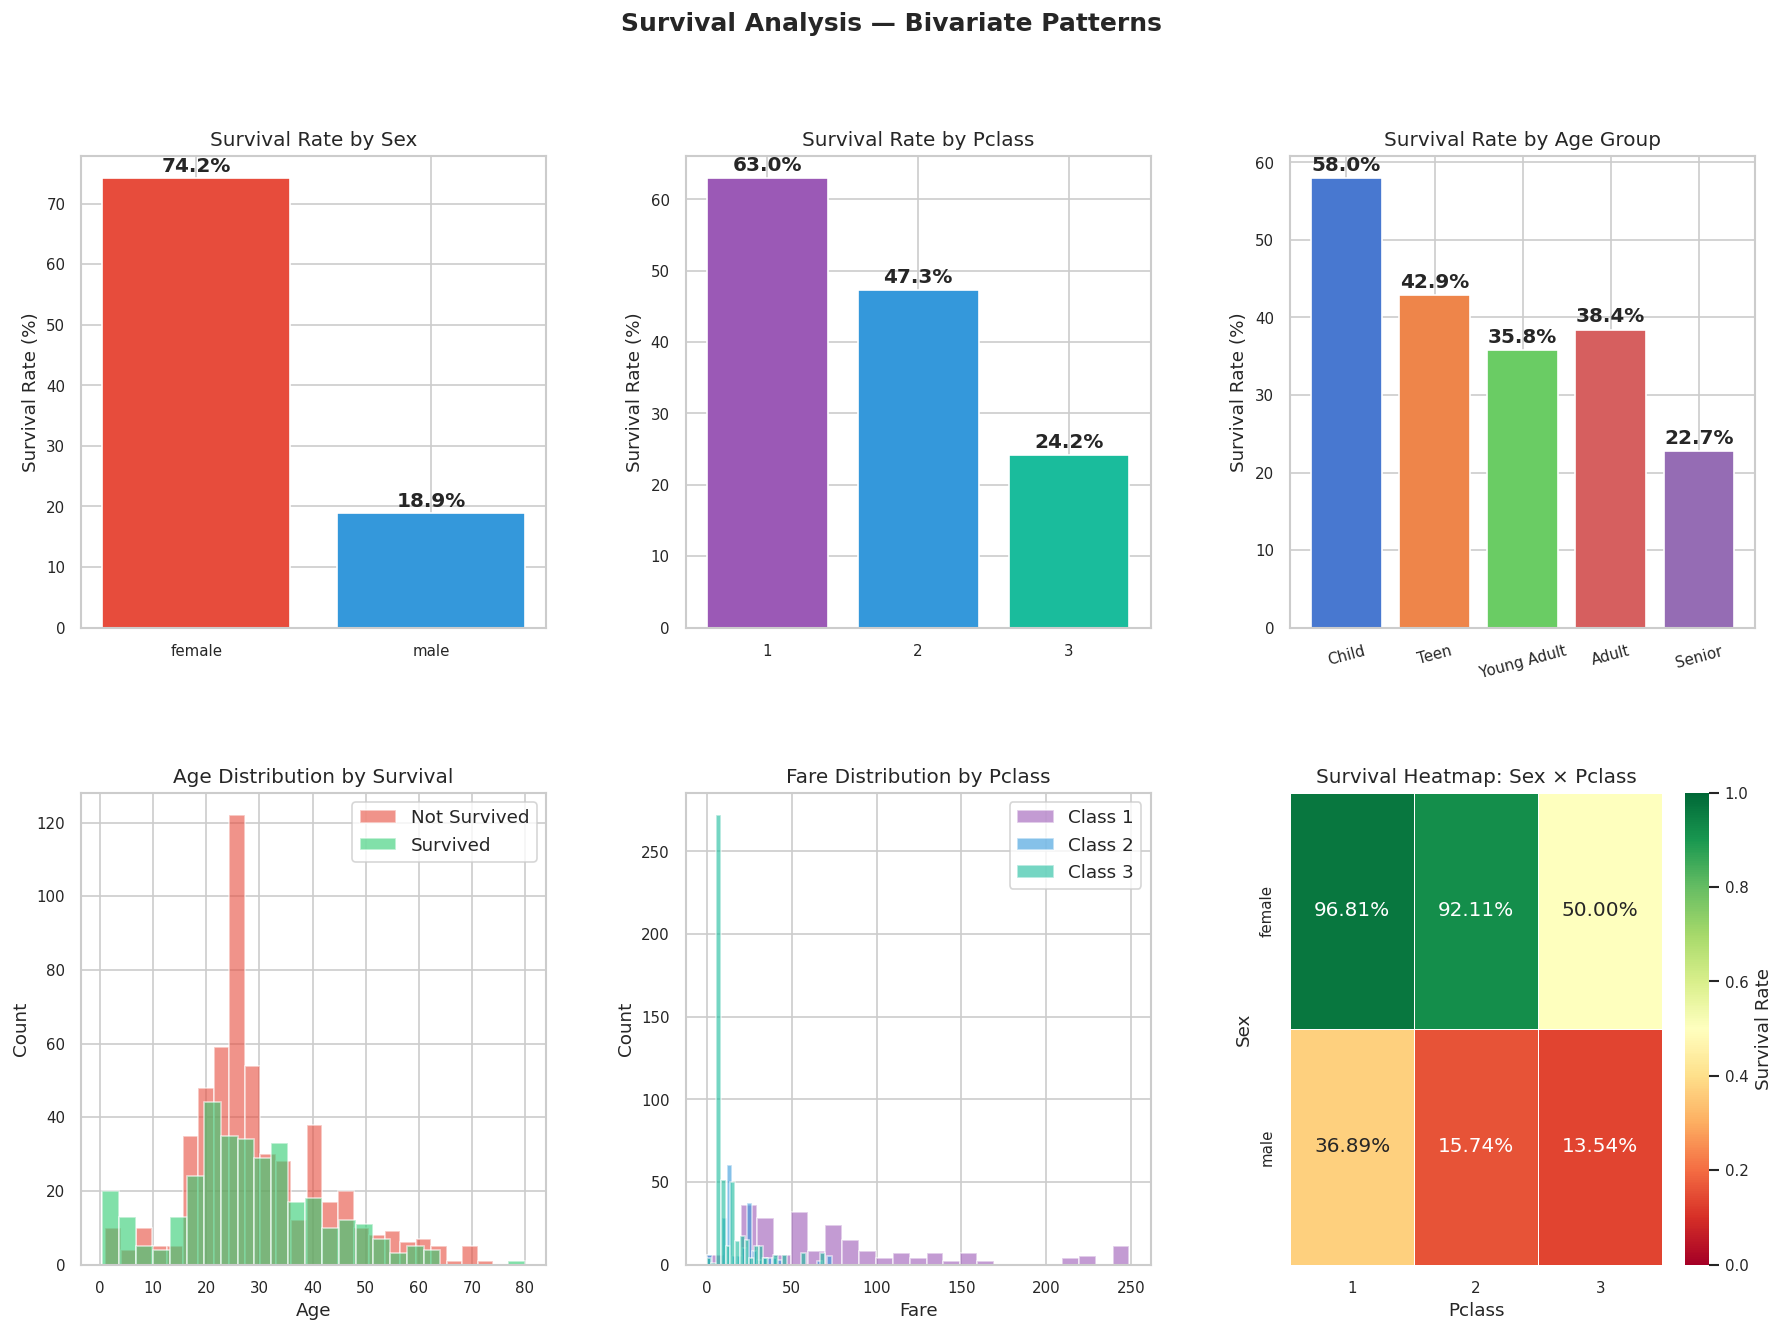

📊 Survival analysis chart saved.


In [6]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Survival Analysis — Bivariate Patterns", fontsize=15, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

SURVIVED_PALETTE = {0: "#E74C3C", 1: "#2ECC71"}

# ── 1. Survival Rate by Sex ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
surv_sex = df.groupby("Sex")["Survived"].mean().reset_index()
bars = ax1.bar(surv_sex["Sex"], surv_sex["Survived"]*100,
               color=["#E74C3C","#3498DB"], edgecolor="white")
ax1.set_title("Survival Rate by Sex")
ax1.set_ylabel("Survival Rate (%)")
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f"{bar.get_height():.1f}%", ha="center", fontweight="bold")

# ── 2. Survival Rate by Pclass ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
surv_pclass = df.groupby("Pclass")["Survived"].mean().reset_index()
bars = ax2.bar(surv_pclass["Pclass"].astype(str), surv_pclass["Survived"]*100,
               color=["#9B59B6","#3498DB","#1ABC9C"], edgecolor="white")
ax2.set_title("Survival Rate by Pclass")
ax2.set_ylabel("Survival Rate (%)")
for bar in bars:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f"{bar.get_height():.1f}%", ha="center", fontweight="bold")

# ── 3. Survival Rate by Age Group ────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
surv_age = df.groupby("Age_Group", observed=True)["Survived"].mean().reset_index()
bars = ax3.bar(surv_age["Age_Group"].astype(str), surv_age["Survived"]*100,
               color=sns.color_palette("muted", len(surv_age)), edgecolor="white")
ax3.set_title("Survival Rate by Age Group")
ax3.set_ylabel("Survival Rate (%)")
ax3.tick_params(axis="x", rotation=15)
for bar in bars:
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f"{bar.get_height():.1f}%", ha="center", fontweight="bold")

# ── 4. Age Distribution by Survival ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for surv, color, label in [(0,"#E74C3C","Not Survived"),(1,"#2ECC71","Survived")]:
    ax4.hist(df[df["Survived"]==surv]["Age"].dropna(), bins=25, alpha=0.6,
             color=color, label=label, edgecolor="white")
ax4.set_title("Age Distribution by Survival")
ax4.set_xlabel("Age"); ax4.set_ylabel("Count")
ax4.legend()

# ── 5. Fare Distribution by Pclass ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
palette_3 = ["#9B59B6","#3498DB","#1ABC9C"]
for pclass, color in zip([1,2,3], palette_3):
    ax5.hist(df[df["Pclass"]==pclass]["Fare"], bins=25, alpha=0.6,
             color=color, label=f"Class {pclass}", edgecolor="white")
ax5.set_title("Fare Distribution by Pclass")
ax5.set_xlabel("Fare"); ax5.set_ylabel("Count")
ax5.legend()

# ── 6. Survival Heatmap: Sex × Pclass ────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
pivot = df.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".2%", cmap="RdYlGn", ax=ax6,
            linewidths=0.5, vmin=0, vmax=1, cbar_kws={"label":"Survival Rate"})
ax6.set_title("Survival Heatmap: Sex × Pclass")

plt.savefig(os.path.join(OUTPUT_DIR, "03_survival_analysis.png"), bbox_inches="tight")
plt.show()
print("📊 Survival analysis chart saved.")


## 📊 Step 7: Pairplot & Correlation Analysis

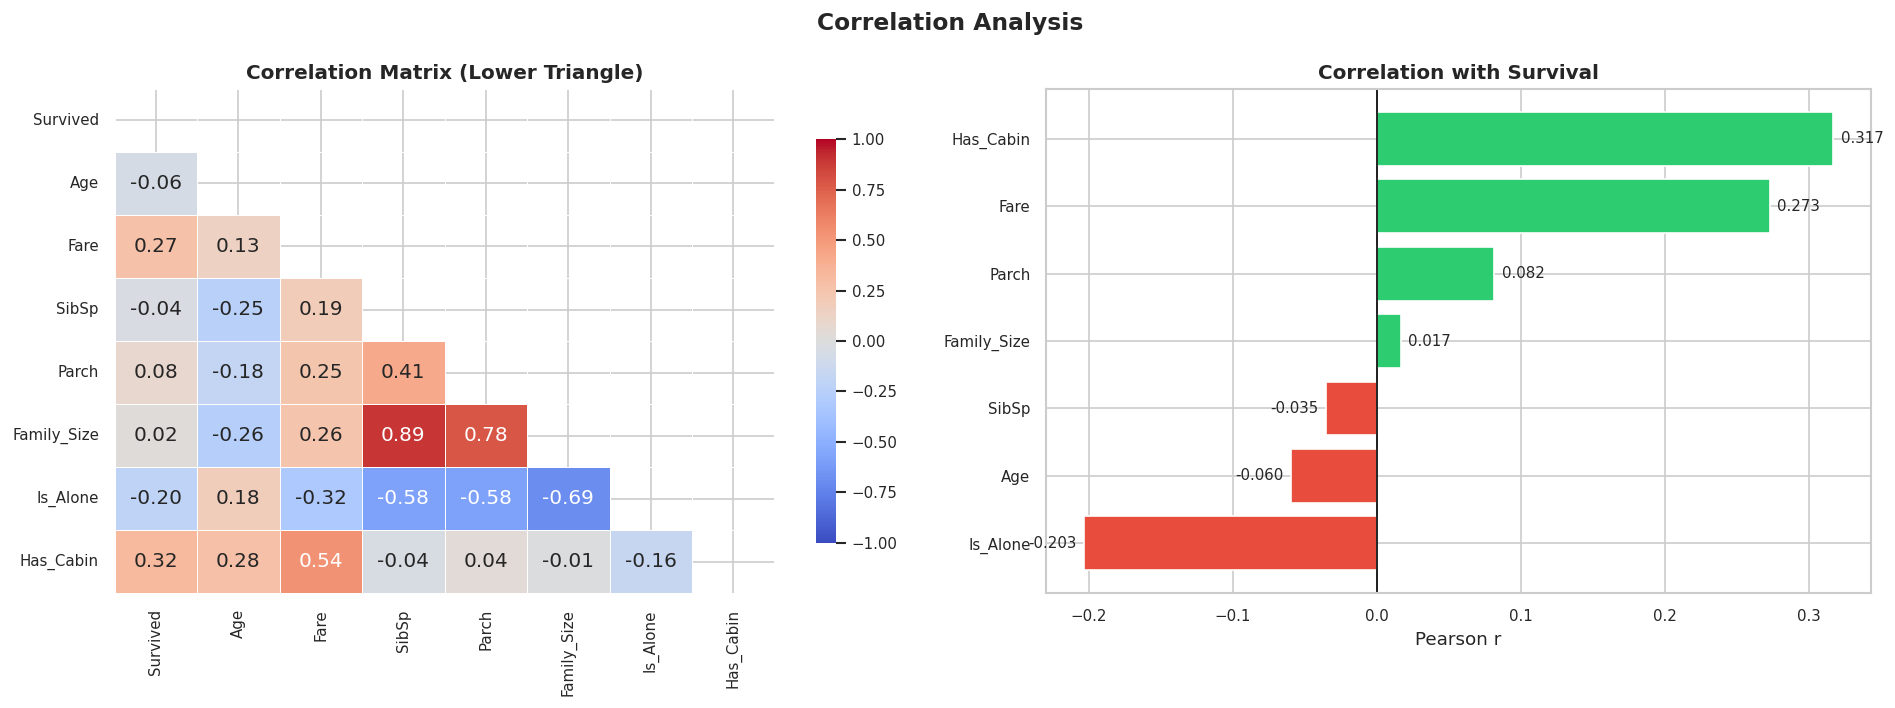

📊 Correlation chart saved.


In [7]:
# Correlation Matrix
num_cols = ["Survived","Age","Fare","SibSp","Parch","Family_Size","Is_Alone","Has_Cabin"]
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlation Analysis", fontsize=14, fontweight="bold")

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[0], linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Correlation Matrix (Lower Triangle)", fontweight="bold")

# Bar chart — correlations with Survived
surv_corr = corr["Survived"].drop("Survived").sort_values()
colors_bar = ["#E74C3C" if v < 0 else "#2ECC71" for v in surv_corr]
axes[1].barh(surv_corr.index, surv_corr.values, color=colors_bar, edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Correlation with Survival", fontweight="bold")
axes[1].set_xlabel("Pearson r")
for i, (idx, val) in enumerate(surv_corr.items()):
    axes[1].text(val + 0.005 if val >= 0 else val - 0.005,
                 i, f"{val:.3f}", va="center",
                 ha="left" if val >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_correlation_analysis.png"), bbox_inches="tight")
plt.show()
print("📊 Correlation chart saved.")


## 📊 Step 8: Multivariate Analysis

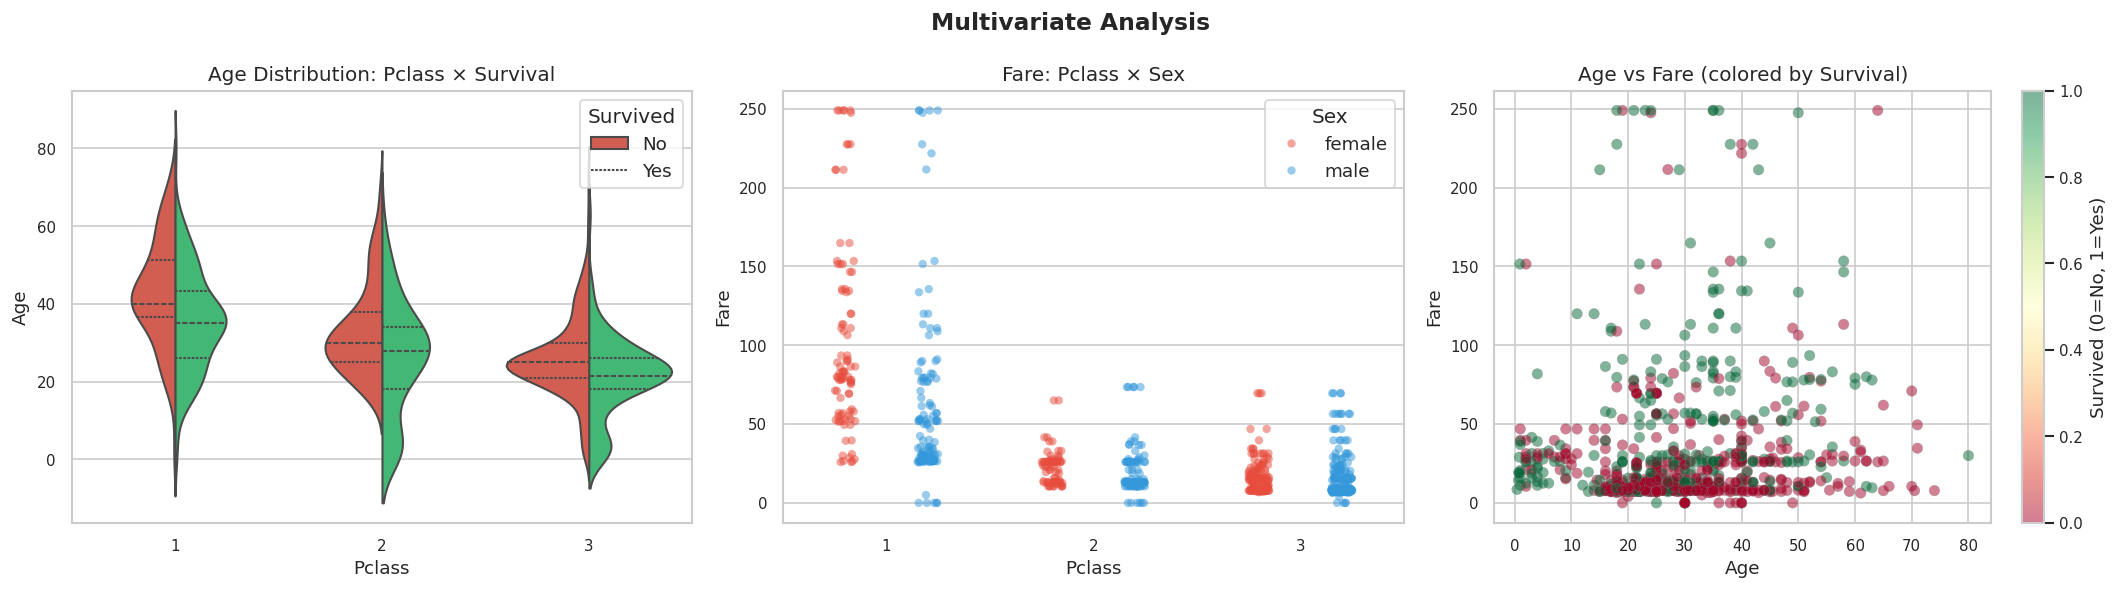

📊 Multivariate chart saved.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Multivariate Analysis", fontsize=14, fontweight="bold")

# Violin: Age by Pclass & Survived
sns.violinplot(data=df, x="Pclass", y="Age", hue="Survived",
               split=True, palette={0:"#E74C3C", 1:"#2ECC71"},
               ax=axes[0], inner="quartile")
axes[0].set_title("Age Distribution: Pclass × Survival")
axes[0].legend(title="Survived", labels=["No","Yes"])

# Strip plot: Fare by Pclass & Sex
sns.stripplot(data=df, x="Pclass", y="Fare", hue="Sex",
              dodge=True, alpha=0.5,
              palette={"male":"#3498DB","female":"#E74C3C"},
              ax=axes[1], jitter=True)
axes[1].set_title("Fare: Pclass × Sex")

# Scatter: Age vs Fare colored by Survival
scatter = axes[2].scatter(df["Age"], df["Fare"],
                          c=df["Survived"], cmap="RdYlGn",
                          alpha=0.5, edgecolors="grey", linewidths=0.3, s=40)
plt.colorbar(scatter, ax=axes[2], label="Survived (0=No, 1=Yes)")
axes[2].set_xlabel("Age"); axes[2].set_ylabel("Fare")
axes[2].set_title("Age vs Fare (colored by Survival)")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_multivariate.png"), bbox_inches="tight")
plt.show()
print("📊 Multivariate chart saved.")


## 📊 Step 9: Embarkation & Family Analysis

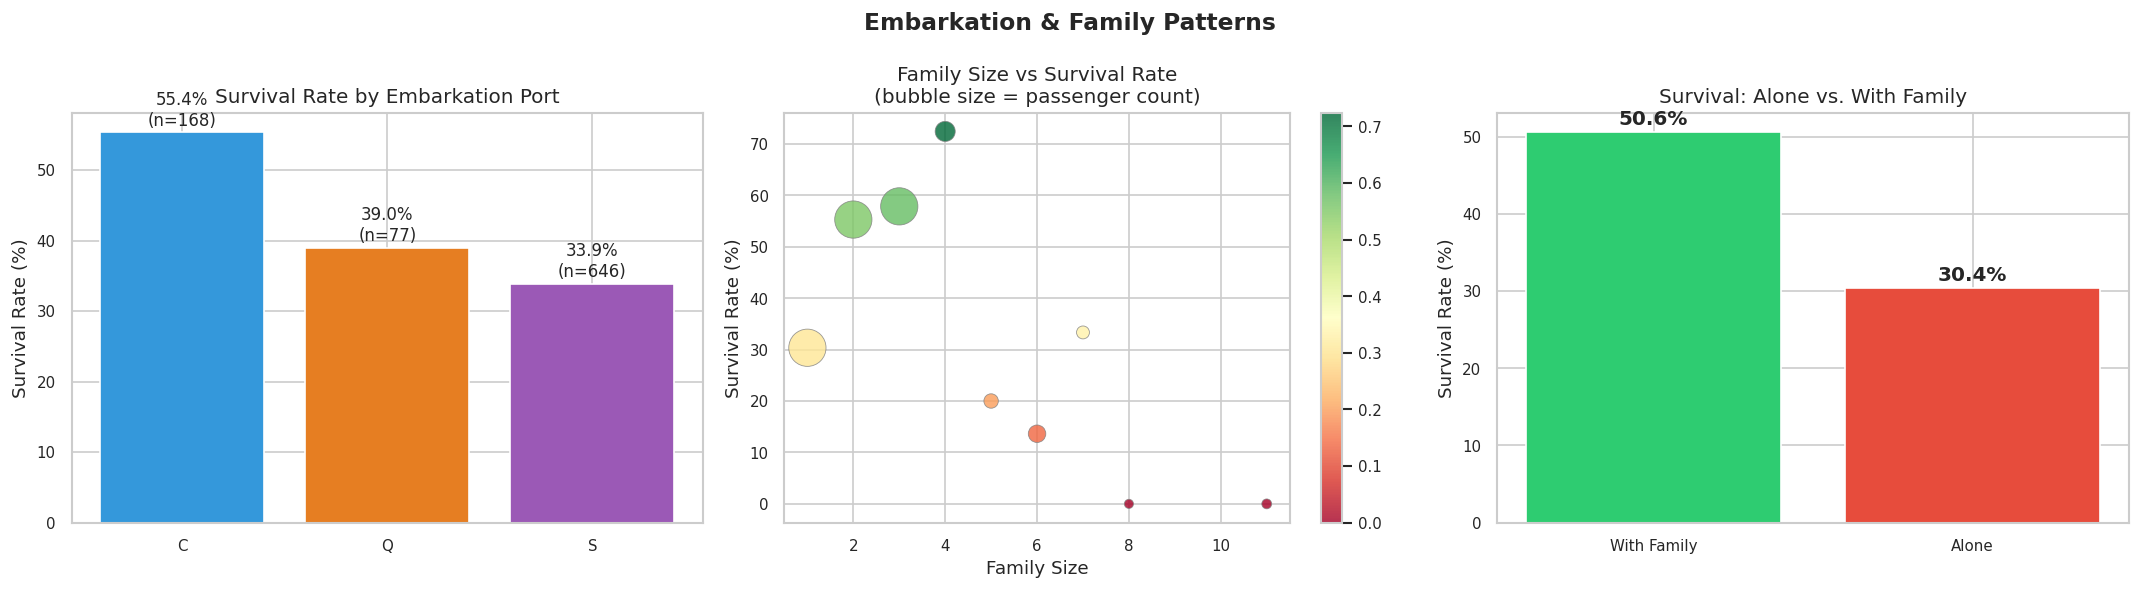

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Embarkation & Family Patterns", fontsize=14, fontweight="bold")

# Survival by Embarkation
emb_surv = df.groupby("Embarked")["Survived"].mean()
emb_cnt  = df["Embarked"].value_counts()
colors   = ["#3498DB","#E67E22","#9B59B6"]
axes[0].bar(emb_surv.index, emb_surv.values*100, color=colors, edgecolor="white")
axes[0].set_title("Survival Rate by Embarkation Port")
axes[0].set_ylabel("Survival Rate (%)")
for i, (port, rate) in enumerate(emb_surv.items()):
    axes[0].text(i, rate*100+1, f"{rate*100:.1f}%\n(n={emb_cnt[port]})",
                 ha="center", fontsize=10)

# Family Size vs Survival Rate
fam_surv = df.groupby("Family_Size")["Survived"].agg(["mean","count"]).reset_index()
fam_surv.columns = ["Family_Size","survival_rate","count"]
sizes = np.clip(fam_surv["count"] * 5, 30, 500)
scatter2 = axes[1].scatter(fam_surv["Family_Size"], fam_surv["survival_rate"]*100,
                           s=sizes, c=fam_surv["survival_rate"], cmap="RdYlGn",
                           edgecolors="grey", linewidths=0.5, alpha=0.8)
axes[1].set_xlabel("Family Size"); axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_title("Family Size vs Survival Rate\n(bubble size = passenger count)")
plt.colorbar(scatter2, ax=axes[1])

# Alone vs Not Alone
alone_surv = df.groupby("Is_Alone")["Survived"].mean()
axes[2].bar(["With Family","Alone"], alone_surv.values*100,
            color=["#2ECC71","#E74C3C"], edgecolor="white")
axes[2].set_title("Survival: Alone vs. With Family")
axes[2].set_ylabel("Survival Rate (%)")
for i, (lbl, val) in enumerate(zip(["With Family","Alone"], alone_surv.values)):
    axes[2].text(i, val*100+1, f"{val*100:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "06_embarkation_family.png"), bbox_inches="tight")
plt.show()

## 📊 Step 10: Statistical Tests

In [12]:
print("=" * 65)
print("           STATISTICAL SIGNIFICANCE TESTS")
print("=" * 65)

# 1. Chi-Square: Sex vs Survived
ct = pd.crosstab(df["Sex"], df["Survived"])
chi2, p_sex, dof, _ = stats.chi2_contingency(ct)
print(f"\n🔹 Chi-Square — Sex vs Survived:")
print(f"   χ² = {chi2:.4f},  p-value = {p_sex:.2e},  dof = {dof}")
print(f"   {'✅ Significant' if p_sex < 0.05 else '❌ Not Significant'} (α = 0.05)")

# 2. Chi-Square: Pclass vs Survived
ct2 = pd.crosstab(df["Pclass"], df["Survived"])
chi2_2, p_pclass, dof2, _ = stats.chi2_contingency(ct2)
print(f"\n🔹 Chi-Square — Pclass vs Survived:")
print(f"   χ² = {chi2_2:.4f},  p-value = {p_pclass:.2e},  dof = {dof2}")
print(f"   {'✅ Significant' if p_pclass < 0.05 else '❌ Not Significant'} (α = 0.05)")

# 3. T-Test: Age survived vs not survived
age_surv     = df[df["Survived"]==1]["Age"].dropna()
age_not_surv = df[df["Survived"]==0]["Age"].dropna()
t_stat, p_age = stats.ttest_ind(age_surv, age_not_surv)
print(f"\n🔹 Independent T-Test — Age: Survived vs Not Survived:")
print(f"   t = {t_stat:.4f},  p-value = {p_age:.4f}")
print(f"   Mean(Survived) = {age_surv.mean():.1f}  |  Mean(Not Survived) = {age_not_surv.mean():.1f}")
print(f"   {'✅ Significant' if p_age < 0.05 else '❌ Not Significant'} (α = 0.05)")

# 4. T-Test: Fare survived vs not survived
fare_surv     = df[df["Survived"]==1]["Fare"].dropna()
fare_not_surv = df[df["Survived"]==0]["Fare"].dropna()
t_fare, p_fare = stats.ttest_ind(fare_surv, fare_not_surv)
print(f"\n🔹 Independent T-Test — Fare: Survived vs Not Survived:")
print(f"   t = {t_fare:.4f},  p-value = {p_fare:.2e}")
print(f"   Mean(Survived) = ${fare_surv.mean():.2f}  |  Mean(Not Survived) = ${fare_not_surv.mean():.2f}")
print(f"   {'✅ Significant' if p_fare < 0.05 else '❌ Not Significant'} (α = 0.05)")
print("=" * 65)


           STATISTICAL SIGNIFICANCE TESTS

🔹 Chi-Square — Sex vs Survived:
   χ² = 260.7170,  p-value = 1.20e-58,  dof = 1
   ✅ Significant (α = 0.05)

🔹 Chi-Square — Pclass vs Survived:
   χ² = 102.8890,  p-value = 4.55e-23,  dof = 2
   ✅ Significant (α = 0.05)

🔹 Independent T-Test — Age: Survived vs Not Survived:
   t = -1.7796,  p-value = 0.0755
   Mean(Survived) = 28.1  |  Mean(Not Survived) = 29.7
   ❌ Not Significant (α = 0.05)

🔹 Independent T-Test — Fare: Survived vs Not Survived:
   t = 8.4615,  p-value = 1.08e-16
   Mean(Survived) = $45.93  |  Mean(Not Survived) = $22.07
   ✅ Significant (α = 0.05)


## 📊 Step 11: Anomaly Detection

In [13]:
print("=" * 60)
print("         ANOMALY & OUTLIER SUMMARY")
print("=" * 60)

for col in ["Age","Fare","Family_Size"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    print(f"\n  🔹 {col}:")
    print(f"     IQR range  : [{lower:.1f}, {upper:.1f}]")
    print(f"     Outliers   : {n_out} ({pct:.1f}%)")

# Check for implausible values
print("\n  🔹 Age extremes:")
print(f"     Min Age = {df['Age'].min():.1f}  |  Max Age = {df['Age'].max():.1f}")
print("\n  🔹 Fare extremes:")
print(f"     Min Fare = ${df['Fare'].min():.2f}  |  Max Fare = ${df['Fare'].max():.2f}")
print("=" * 60)


         ANOMALY & OUTLIER SUMMARY

  🔹 Age:
     IQR range  : [-0.2, 57.8]
     Outliers   : 33 (3.7%)

  🔹 Fare:
     IQR range  : [-26.7, 65.6]
     Outliers   : 116 (13.0%)

  🔹 Family_Size:
     IQR range  : [-0.5, 3.5]
     Outliers   : 91 (10.2%)

  🔹 Age extremes:
     Min Age = 0.4  |  Max Age = 80.0

  🔹 Fare extremes:
     Min Fare = $0.00  |  Max Fare = $249.01


## 📝 Step 12: Key Insights & EDA Summary

In [14]:
surv_rate    = df["Survived"].mean() * 100
female_surv  = df[df["Sex"]=="female"]["Survived"].mean() * 100
male_surv    = df[df["Sex"]=="male"]["Survived"].mean() * 100
class1_surv  = df[df["Pclass"]==1]["Survived"].mean() * 100
class3_surv  = df[df["Pclass"]==3]["Survived"].mean() * 100
child_surv   = df[df["Age_Group"]=="Child"]["Survived"].mean() * 100
alone_surv_r = df[df["Is_Alone"]==1]["Survived"].mean() * 100
family_surv  = df[df["Is_Alone"]==0]["Survived"].mean() * 100

print("=" * 65)
print("               KEY INSIGHTS FROM EDA")
print("=" * 65)
print(f"\n📌 Overall Survival Rate        : {surv_rate:.1f}%")
print(f"\n📌 Survival by Gender:")
print(f"   Females : {female_surv:.1f}%  |  Males : {male_surv:.1f}%")
print(f"   → Women survived at {female_surv/male_surv:.1f}x the rate of men (Women & Children First policy)")
print(f"\n📌 Survival by Passenger Class:")
print(f"   1st Class : {class1_surv:.1f}%  |  3rd Class : {class3_surv:.1f}%")
print(f"   → 1st class passengers survived at {class1_surv/class3_surv:.1f}x the rate of 3rd class")
print(f"\n📌 Children (under 12) Survival : {child_surv:.1f}%")
print(f"\n📌 Traveling Alone   Survival   : {alone_surv_r:.1f}%")
print(f"   With Family Survival         : {family_surv:.1f}%")
print(f"\n📌 Top Positive Correlations with Survival:")
corr_surv = df[["Survived","Age","Fare","Family_Size","Is_Alone","Has_Cabin"]].corr()["Survived"].drop("Survived").sort_values(ascending=False)
for feat, val in corr_surv.items():
    arrow = "↑" if val > 0 else "↓"
    print(f"   {arrow} {feat:<20}: r = {val:>+.3f}")
print("=" * 65)
print("\n✅ Task 3 — EDA COMPLETE")


               KEY INSIGHTS FROM EDA

📌 Overall Survival Rate        : 38.4%

📌 Survival by Gender:
   Females : 74.2%  |  Males : 18.9%
   → Women survived at 3.9x the rate of men (Women & Children First policy)

📌 Survival by Passenger Class:
   1st Class : 63.0%  |  3rd Class : 24.2%
   → 1st class passengers survived at 2.6x the rate of 3rd class

📌 Children (under 12) Survival : 58.0%

📌 Traveling Alone   Survival   : 30.4%
   With Family Survival         : 50.6%

📌 Top Positive Correlations with Survival:
   ↑ Has_Cabin           : r = +0.317
   ↑ Fare                : r = +0.273
   ↑ Family_Size         : r = +0.017
   ↓ Age                 : r = -0.060
   ↓ Is_Alone            : r = -0.203

✅ Task 3 — EDA COMPLETE


## 💾 Step 13: List Saved Output Files

In [17]:
print("📁 EDA Output Files:\n")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    print(f"  📊 {fname:<45}  {os.path.getsize(fpath)/1024:>7.1f} KB")


📁 EDA Output Files:

  📊 01_univariate_numerical.png                      219.0 KB
  📊 02_univariate_categorical.png                     81.1 KB
  📊 03_survival_analysis.png                         145.5 KB
  📊 04_correlation_analysis.png                      100.4 KB
  📊 05_multivariate.png                              203.7 KB
  📊 06_embarkation_family.png                         80.0 KB


---
## 📝 Task 3 Summary

| Analysis | Key Finding |
|----------|------------|
| **Overall Survival** | 38.4% of passengers survived |
| **Gender Effect** | Females survived at ~74% vs males at ~19% |
| **Class Effect** | 1st class: ~63% vs 3rd class: ~24% survival |
| **Age** | Children had the highest survival rate |
| **Family Size** | Small families (2–4) survived better than solo travelers |
| **Fare** | Higher fare strongly correlated with survival (r ≈ +0.26) |
| **Statistical Tests** | Sex and Pclass: χ² p < 0.001 — highly significant |

### 📊 Visualizations Created:
1. Univariate Numerical — Histograms, Boxplots, Q-Q Plots
2. Univariate Categorical — Count Bars
3. Survival Analysis — Sex, Pclass, Age Group, Heatmap
4. Correlation Matrix & Survival Correlations
5. Multivariate — Violin, Strip, Scatter
6. Embarkation & Family Analysis

> ✅ **Task 3 Complete** — Comprehensive EDA performed with 6 visualization panels, statistical tests, and actionable insights derived.
